# Kasarani Riparian Encroachment — Building Feature Extraction, Auto-Labeling & RF Training

Real-data pipeline:
1. Extract per-building pixel statistics from the Sentinel-2 tile
2. Auto-label buildings by real distance to river (60m legal buffer), clipped to the AOI
3. Train a Random Forest on the labeled table



In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---- File paths: edit these to match where your files actually live ----
RASTER_PATH = "kasarani_sentinel_tile.tif"
BUILDINGS_PATH = "kasarani_buildings_export.geojson"
RIVER_PATH = "kasarani_river.gpkg"
AOI_PATH = "kasarani_aoi.gpkg"

FEATURES_CSV = "kasarani_building_features.csv"
LABELED_CSV = "kasarani_building_features_labeled.csv"
MODEL_OUTPUT_PATH = "riparian_rf_model.joblib"
FIGURES_DIR = "runs"

BUFFER_METERS = 60          # legal riparian buffer used for auto-labeling
TARGET_CRS = "EPSG:32737"   # UTM 37S — matches river/AOI layers, metric units

os.makedirs(FIGURES_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Inspect the raw inputs

All four files must already exist — this notebook does not generate mock
geometry or synthetic pixel values if they're missing.

In [2]:
def require_file(path, how_to_produce):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing required input: {path}\nHow to produce it: {how_to_produce}"
        )

require_file(RASTER_PATH, "Export the Sentinel-2 composite GeoTIFF and place it at this path.")
require_file(BUILDINGS_PATH, "Export the buildings footprint layer (GeoJSON/Shapefile) to this path.")
require_file(RIVER_PATH, "Export the river/waterway layer for Kasarani (GeoPackage) to this path.")
require_file(AOI_PATH, "Export the Kasarani AOI boundary (GeoPackage) to this path.")

with rasterio.open(RASTER_PATH) as src:
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    print("Bands:", src.count, src.descriptions)

buildings_raw = gpd.read_file(BUILDINGS_PATH)
river_raw = gpd.read_file(RIVER_PATH)
aoi_raw = gpd.read_file(AOI_PATH)

print("\nBuildings:", len(buildings_raw), "| CRS:", buildings_raw.crs)
print("River features:", len(river_raw), "| CRS:", river_raw.crs)
print("AOI polygons:", len(aoi_raw), "| CRS:", aoi_raw.crs)

Raster CRS: EPSG:32737
Raster bounds: BoundingBox(left=258720.0, bottom=9860140.0, right=278250.0, top=9871640.0)
Bands: 3 ('B4', 'B3', 'B2')

Buildings: 57422 | CRS: EPSG:4326
River features: 21 | CRS: EPSG:32737
AOI polygons: 1 | CRS: EPSG:32737


## 2. Build real per-building zonal statistics

Computes mean/std pixel value per band under each building footprint. This
raster only has bands B4/B3/B2 (true-color RGB) — no NIR/SWIR — so NDVI/NDWI
cannot be derived from it.

In [3]:
BAND_NAMES = ["R", "G", "B"]  # matches this tile's B4, B3, B2 order

with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs
    affine = src.transform
    bands = [src.read(i + 1) for i in range(src.count)]

buildings = buildings_raw[buildings_raw.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
dropped = len(buildings_raw) - len(buildings)
if dropped:
    print(f"Dropped {dropped} non-polygon geometries before zonal stats.")

buildings = buildings.to_crs(raster_crs)

feature_frames = []
for band_arr, name in zip(bands, BAND_NAMES):
    stats = zonal_stats(buildings, band_arr, affine=affine, stats=["mean", "std"],
                         nodata=np.nan, all_touched=True)
    df = pd.DataFrame(stats).rename(columns={"mean": f"{name}_mean", "std": f"{name}_std"})
    feature_frames.append(df)

features = pd.concat(feature_frames, axis=1)
features["id"] = buildings["id"].values
features["area_m2"] = buildings.geometry.area.values

before = len(features)
features = features.dropna()
if before - len(features):
    print(f"Dropped {before - len(features)} buildings with no valid pixels under their footprint.")

cols = ["id"] + [f"{n}_mean" for n in BAND_NAMES] + [f"{n}_std" for n in BAND_NAMES] + ["area_m2"]
features = features[cols]
features.to_csv(FEATURES_CSV, index=False)
print(f"Wrote {len(features)} rows to {FEATURES_CSV}")
features.head()

Dropped 19 non-polygon geometries before zonal stats.
Wrote 57403 rows to kasarani_building_features.csv


,id,R_mean,G_mean,B_mean,R_std,G_std,B_std,area_m2
0,0018000000000002200f,1113.200000,957.400000,693.200000,54.370580,42.837367,52.059197,107.753103
1,0018000000000002c731,1135.250000,1303.666667,1792.000000,226.342338,266.839319,449.158472,409.879856
2,00180000000000010adb,1114.500000,976.500000,780.250000,70.531908,59.302192,96.882338,132.463264
3,0018000000000002af35,844.636364,754.909091,543.454545,77.784402,52.293672,35.955436,367.178332
4,0018000000000000f10b,1751.666667,1431.666667,1138.333333,171.025989,123.122793,107.600599,211.139095


## 3. Auto-label buildings by real distance to river

Clips buildings to the AOI, computes each building centroid's distance to the
nearest real river feature, and labels `encroachment = 1` if that distance is
within the legal 60m buffer, else `0`. This is a real, deterministic label —
not a placeholder.

In [4]:
buildings_m = buildings_raw[buildings_raw.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
buildings_m = buildings_m.to_crs(TARGET_CRS)

river = river_raw.to_crs(TARGET_CRS)
aoi = aoi_raw.to_crs(TARGET_CRS)

aoi_geom = aoi.union_all() if hasattr(aoi, "union_all") else aoi.unary_union
before = len(buildings_m)
buildings_m = buildings_m[buildings_m.geometry.centroid.within(aoi_geom)].copy()
print(f"Clipped to AOI: {before} -> {len(buildings_m)} buildings.")

river_union = river.union_all() if hasattr(river, "union_all") else river.unary_union
centroids = buildings_m.geometry.centroid
buildings_m["dist_to_river_m"] = centroids.distance(river_union)
buildings_m["encroachment"] = (buildings_m["dist_to_river_m"] <= BUFFER_METERS).astype(int)

print("\nEncroachment label distribution:")
print(buildings_m["encroachment"].value_counts())

labels = buildings_m[["id", "dist_to_river_m", "encroachment"]]

labeled = features.merge(labels, on="id", how="inner")
dropped = len(features) - len(labeled)
if dropped:
    print(f"\nDropped {dropped} rows with no matching AOI-clipped building.")

labeled.to_csv(LABELED_CSV, index=False)
print(f"\nWrote {len(labeled)} labeled rows to {LABELED_CSV}")
labeled.head()

Clipped to AOI: 57403 -> 57367 buildings.

Encroachment label distribution:
encroachment
0    56169
1     1198
Name: count, dtype: int64

Dropped 36 rows with no matching AOI-clipped building.

Wrote 57367 labeled rows to kasarani_building_features_labeled.csv


,id,R_mean,G_mean,B_mean,R_std,G_std,B_std,area_m2,dist_to_river_m,encroachment
0,0018000000000002200f,1113.200000,957.400000,693.200000,54.370580,42.837367,52.059197,107.753103,2315.479382,0
1,0018000000000002c731,1135.250000,1303.666667,1792.000000,226.342338,266.839319,449.158472,409.879856,23.133404,1
2,00180000000000010adb,1114.500000,976.500000,780.250000,70.531908,59.302192,96.882338,132.463264,309.356423,0
3,0018000000000002af35,844.636364,754.909091,543.454545,77.784402,52.293672,35.955436,367.178332,916.524245,0
4,0018000000000000f10b,1751.666667,1431.666667,1138.333333,171.025989,123.122793,107.600599,211.139095,166.104750,0


## 4. Train / test split, model training, evaluation, export

**Note on features:** `dist_to_river_m` is excluded from training. It's what
`encroachment` was directly thresholded from, so including it would let the
model just re-learn that threshold instead of testing whether the R/G/B
spectral signature says anything about encroachment. It stays in the CSV for
your own QA, not for the model.

**Note on class balance:** encroaching buildings are a small minority of the
total (~2%), so `class_weight="balanced"` is used, and accuracy alone isn't a
meaningful metric here — check precision/recall/F1 for the encroachment
class specifically.

In [5]:
TARGET_COLUMN = "encroachment"
EXCLUDE_COLUMNS = ["id", "dist_to_river_m", TARGET_COLUMN]

if TARGET_COLUMN not in labeled.columns:
    raise ValueError(f"'{TARGET_COLUMN}' not found in the labeled table.")

feature_cols = [c for c in labeled.columns if c not in EXCLUDE_COLUMNS]
X = labeled[feature_cols]
y = labeled[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=42, n_jobs=-1,
    class_weight="balanced",
)
model.fit(X_train, y_train)
print(f"Trained on {len(X_train)} samples, testing on {len(X_test)}.")
print(f"Features used: {feature_cols}")

Trained on 40156 samples, testing on 17211.
Features used: ['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std', 'area_m2']


Accuracy: 0.9161582708732787

              precision    recall  f1-score   support

           0       0.98      0.93      0.96     16852
           1       0.04      0.13      0.06       359

    accuracy                           0.92     17211
   macro avg       0.51      0.53      0.51     17211
weighted avg       0.96      0.92      0.94     17211



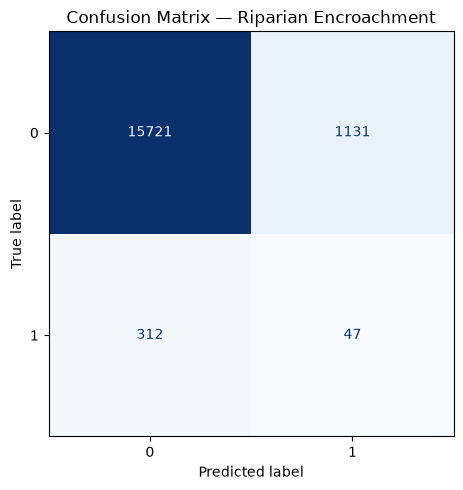

In [6]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Riparian Encroachment")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrix.png"), dpi=200)
plt.show()

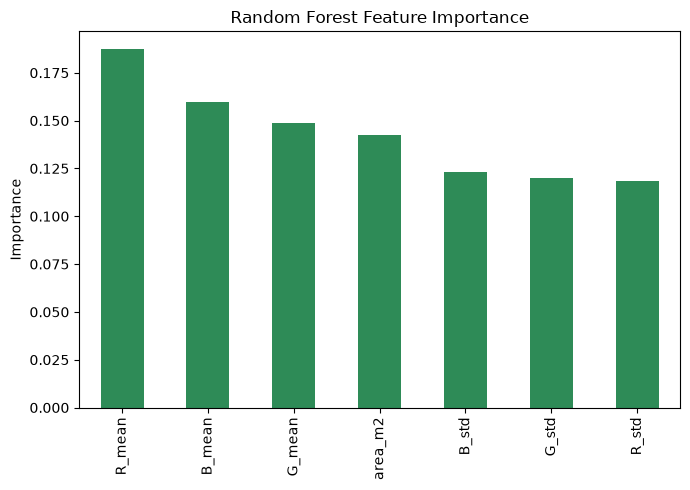

R_mean     0.187295
B_mean     0.159675
G_mean     0.148916
area_m2    0.142350
B_std      0.123359
G_std      0.119888
R_std      0.118518
dtype: float64

In [7]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="bar", ax=ax, color="seagreen")
ax.set_ylabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_importance.png"), dpi=200)
plt.show()

importances

In [8]:
joblib.dump(model, MODEL_OUTPUT_PATH)
print(f"Model saved: {MODEL_OUTPUT_PATH}")

Model saved: riparian_rf_model.joblib
